In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
# ['char', 'token', 'shuffle']
PTB_TYPE = 'shuffle'
percentages = [x*5 for x in range(1, 11)] if PTB_TYPE != 'shuffle' else [x*5 for x in range(1, 21)]

# Utils

In [3]:
def avg_by_token(df):
    seqs = df.groupby('sample').mean()
    return seqs

# Zero ptb

In [4]:
sequence_baseline = pd.read_csv('results/char/0/sequence_evals.csv')

In [5]:
token_baseline =  pd.read_csv('results/char/0/token_evals.csv')

In [6]:
avg_by_token(token_baseline)

,token_in_sample,top50_divergence,activation_cos_sim_layer_0,activation_l2_dist_layer_0,activation_cos_sim_layer_1,activation_l2_dist_layer_1,activation_cos_sim_layer_2,activation_l2_dist_layer_2,activation_cos_sim_layer_3,activation_l2_dist_layer_3,...,ptb_attn_layer11_head_2_entropy,ptb_attn_layer11_head_3_entropy,ptb_attn_layer11_head_4_entropy,ptb_attn_layer11_head_5_entropy,ptb_attn_layer11_head_6_entropy,ptb_attn_layer11_head_7_entropy,ptb_attn_layer11_head_8_entropy,ptb_attn_layer11_head_9_entropy,ptb_attn_layer11_head_10_entropy,ptb_attn_layer11_head_11_entropy
sample,,,,,,,,,,,,,,,,,,,,,
0,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,2.124280,2.259094,2.686953,1.678854,1.716854,2.278790,2.939922,1.368702,2.647907,2.524220
1,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.989601,2.100020,2.619655,1.667770,1.517503,2.054106,2.817376,1.440403,2.556079,2.371022
2,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.584450,1.357557,2.527658,1.882939,1.390420,1.861779,2.763454,1.293533,2.353321,2.356273
3,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.939133,2.412661,2.591767,1.759035,1.480752,1.970662,2.918693,1.536814,2.381232,2.282339
16,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.844138,2.131442,2.578810,1.463009,1.399990,1.892591,2.786791,1.196449,2.134512,2.374584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.501765,2.290569,2.646328,1.669757,1.380653,1.750923,2.839246,1.433461,2.304365,2.349217
384,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.496355,1.819448,2.348371,1.515747,1.624402,1.542332,2.910809,1.483265,1.629688,2.042901
385,63.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,1.832300,1.685540,2.609209,1.902472,1.986367,1.826063,2.939602,1.730809,1.852147,2.113409


# Output Level Metrics

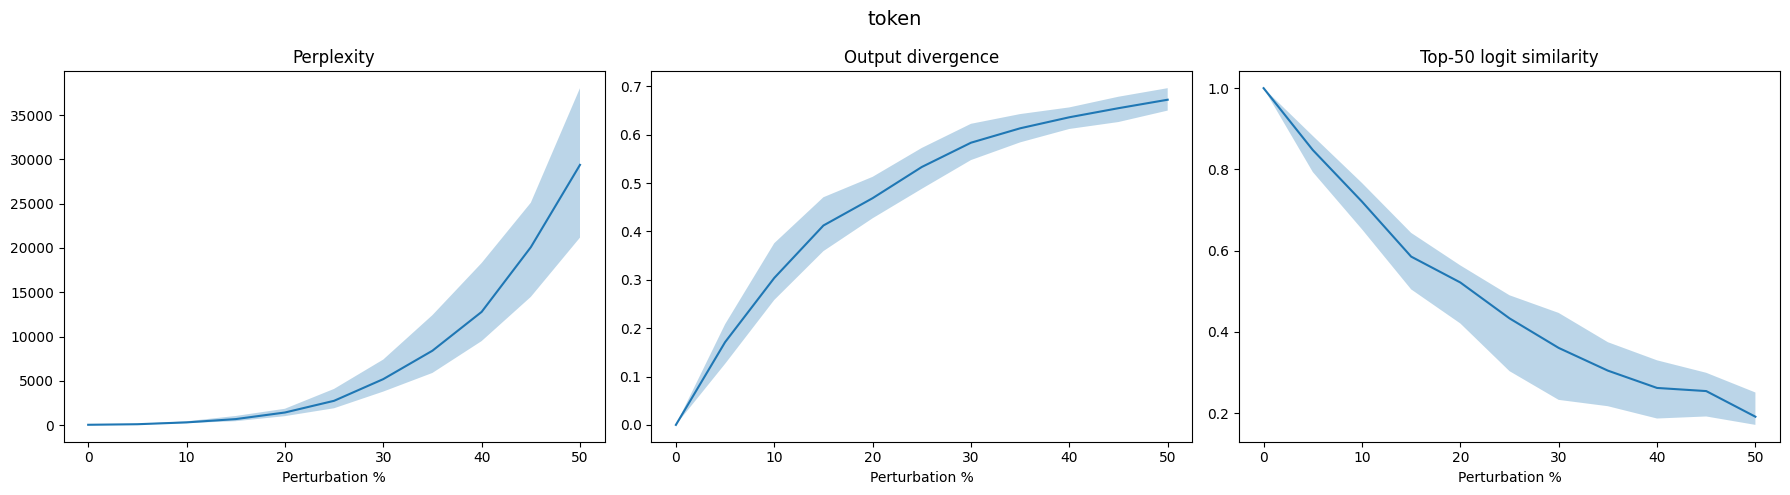

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(PTB_TYPE, fontsize=14)

# --- perplexity ---
means = [np.median(sequence_baseline['perplexity'])]
lows  = [np.percentile(sequence_baseline['perplexity'], 25)]
highs = [np.percentile(sequence_baseline['perplexity'], 75)]

for pct in percentages:
    seq = pd.read_csv(f'results/{PTB_TYPE}/{pct}/sequence_evals.csv')
    means.append(np.median(seq['perplexity']))
    lows.append(np.percentile(seq['perplexity'], 25))
    highs.append(np.percentile(seq['perplexity'], 75))

xs = np.array([0] + percentages)
ax1.plot(xs, means)
ax1.fill_between(xs, lows, highs, alpha=0.3)
ax1.set_title('Perplexity')
ax1.set_xlabel('Perturbation %')

# --- output divergence ---
means = [0]
lows  = [0]
highs = [0]

for pct in percentages:
    seq = pd.read_csv(f'results/{PTB_TYPE}/{pct}/sequence_evals.csv')
    means.append(np.median(seq['output_divergence']))
    lows.append(np.percentile(seq['output_divergence'], 25))
    highs.append(np.percentile(seq['output_divergence'], 75))

xs = np.array([0] + percentages)
ax2.plot(xs, means)
ax2.fill_between(xs, lows, highs, alpha=0.3)
ax2.set_title('Output divergence')
ax2.set_xlabel('Perturbation %')

# --- top-50 logit similarity ---
means = [1]
lows  = [1]
highs = [1]

for pct in percentages:
    seq = pd.read_csv(f'results/{PTB_TYPE}/{pct}/token_evals.csv')
    seq = avg_by_token(seq)
    means.append(np.median(seq['top50_divergence']))
    lows.append(np.percentile(seq['top50_divergence'], 25))
    highs.append(np.percentile(seq['top50_divergence'], 75))

xs = np.array([0] + percentages)
ax3.plot(xs, means)
ax3.fill_between(xs, lows, highs, alpha=0.3)
ax3.set_title('Top-50 logit similarity')
ax3.set_xlabel('Perturbation %')

plt.tight_layout()
plt.savefig(f'results/{PTB_TYPE}_output_metrics.png', bbox_inches='tight', dpi=150)

## Activation Similarity

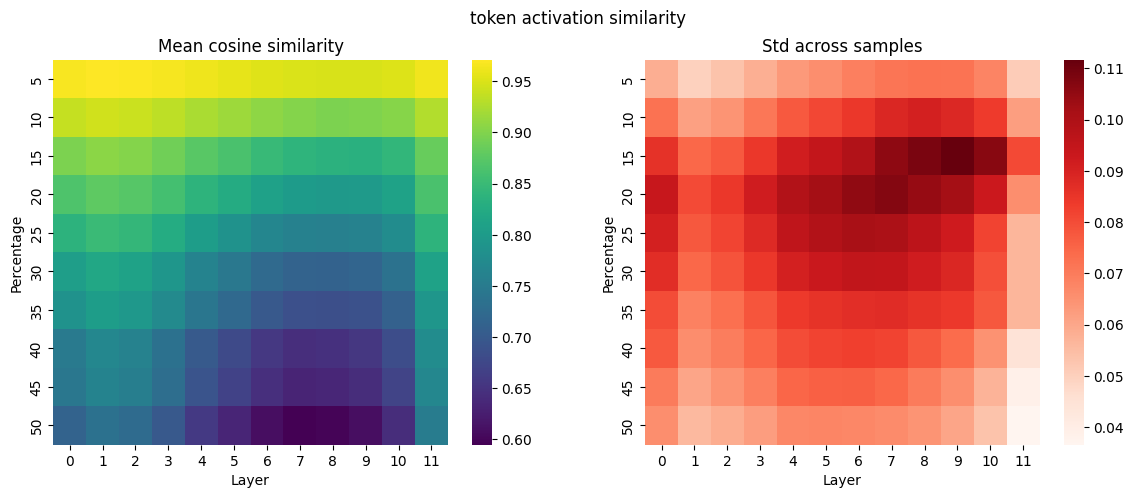

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

mean_matrix = []
std_matrix = []

for pct in percentages:
    seq =  pd.read_csv(f'results/{PTB_TYPE}/{pct}/token_evals.csv')
    seq = avg_by_token(seq)
    means = []
    stds = []
    for i in range(12):
        means.append(np.mean(seq[f'activation_cos_sim_layer_{i}']))
        stds.append(np.std(seq[f'activation_cos_sim_layer_{i}']))
    
    mean_matrix.append(means)
    std_matrix.append(stds)

mean_matrix = np.array(mean_matrix)
std_matrix = np.array(std_matrix)

sns.heatmap(mean_matrix, ax=ax1, cmap='viridis', yticklabels=percentages)
ax1.set_title('Mean cosine similarity')
ax1.set_xlabel('Layer')
ax1.set_ylabel('Percentage')

sns.heatmap(std_matrix, ax=ax2, cmap='Reds', yticklabels=percentages)
ax2.set_title('Std across samples')
ax2.set_xlabel('Layer')
ax2.set_ylabel('Percentage')

fig.suptitle(PTB_TYPE+' activation similarity')
plt.savefig(f'results/{PTB_TYPE}_activation_similarity.png')

## Attention Entropy

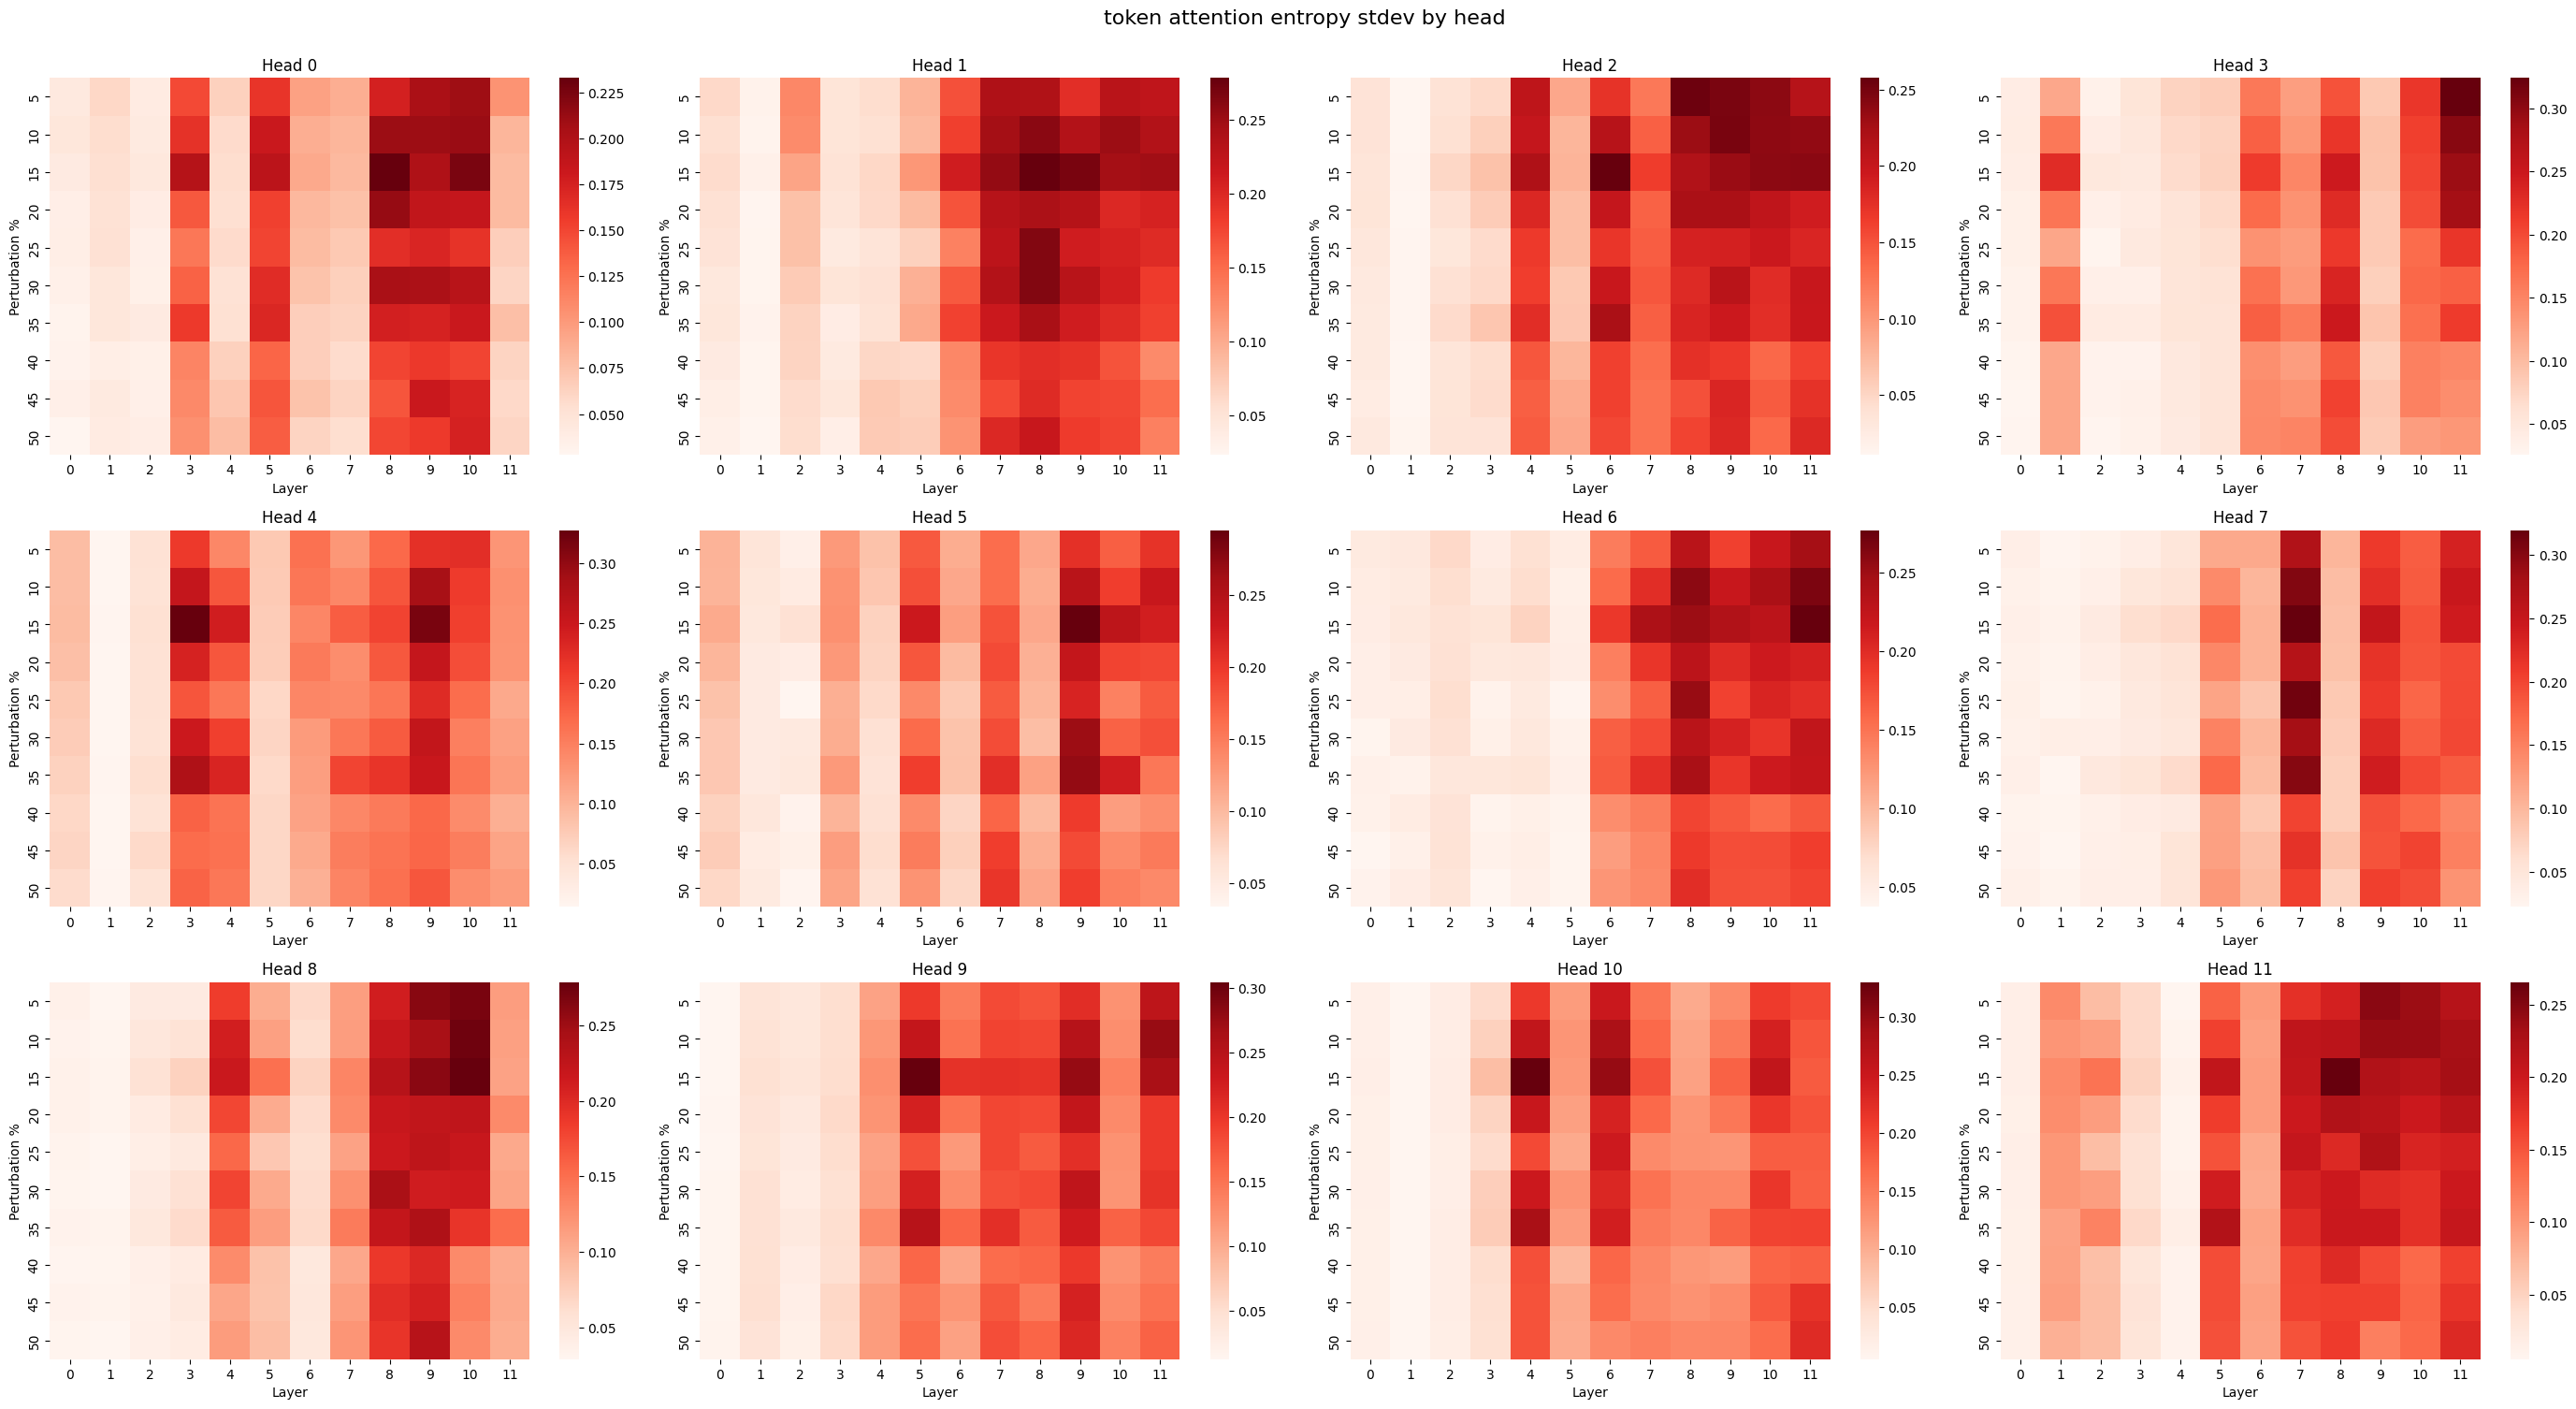

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(28, 15))
fig.suptitle(f'{PTB_TYPE} attention entropy stdev by head', fontsize=16, y=1.001)

for h in range(12):
    row = (h // 4)
    col = (h % 4)

    std_matrix = []

    for pct in percentages:
        seq = pd.read_csv(f'results/{PTB_TYPE}/{pct}/token_evals.csv')
        seq = avg_by_token(seq)
        stds = []
        for i in range(12):
            stds.append(np.std(seq[f'ptb_attn_layer{i}_head_{h}_entropy']))

        std_matrix.append(stds)

    std_matrix = np.array(std_matrix)
    ax = axes[row,col]

    sns.heatmap(std_matrix, ax=ax, cmap='Reds', yticklabels=percentages)
    ax.set_title(f'Head {h}')
    ax.set_xlabel('Layer')
    ax.set_ylabel('Perturbation %')

plt.tight_layout()
plt.savefig(f'results/{PTB_TYPE}_attention_entropy_all_heads.png',
            bbox_inches='tight', dpi=150)

In [10]:
def entropy_slope_by_head(ptb_type, percentages, avg_by_token):
    import numpy as np
    from scipy import stats
    
    entropy_by_pct = []
    
    for pct in percentages:
        seq = pd.read_csv(f'results/{ptb_type}/{pct}/token_evals.csv')
        seq = avg_by_token(seq)
        
        layer_head_means = []
        for i in range(12):
            head_means = []
            for h in range(12):
                col = f'ptb_attn_layer{i}_head_{h}_entropy'
                head_means.append(np.mean(seq[col]))
            layer_head_means.append(head_means)
        entropy_by_pct.append(layer_head_means)
    
    entropy_by_pct = np.array(entropy_by_pct)
    
    slopes = np.zeros((12, 12))
    for i in range(12):
        for h in range(12):
            slope, _, _, _, _ = stats.linregress(percentages, entropy_by_pct[:, i, h])
            slopes[i, h] = slope
    
    return slopes

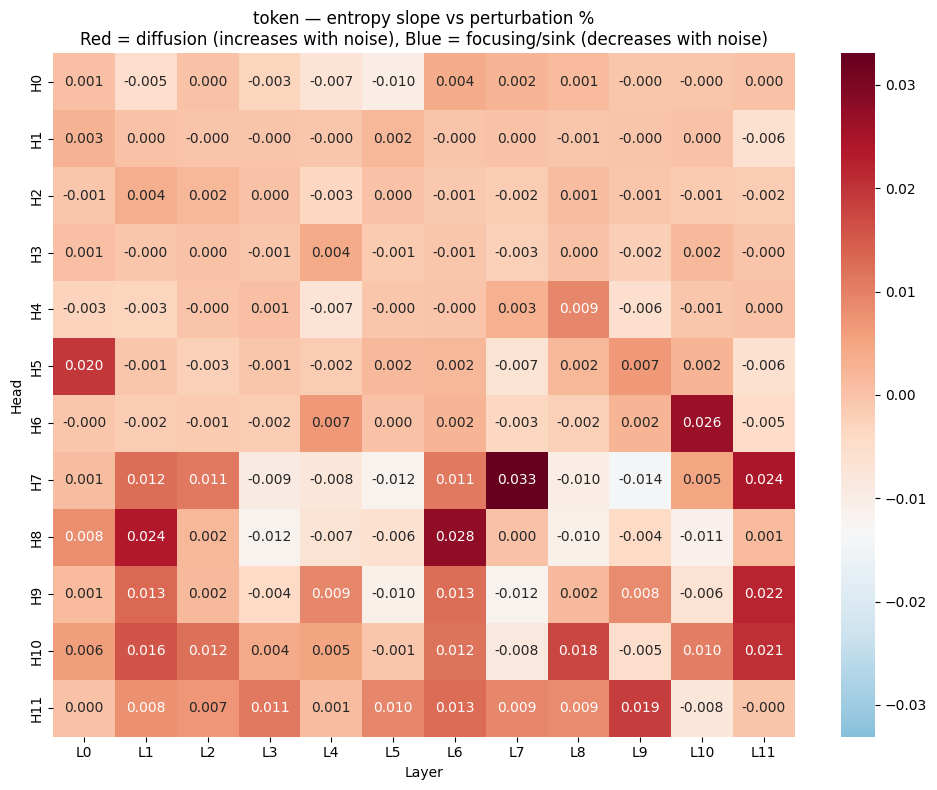

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

slopes = entropy_slope_by_head(PTB_TYPE, percentages, avg_by_token)

fig, ax = plt.subplots(figsize=(10, 8))

# Diverging colormap centered at 0
vmax = np.abs(slopes).max()
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

sns.heatmap(
    slopes,
    ax=ax,
    cmap='RdBu_r',       # red = increasing (diffusion), blue = decreasing (focusing)
    norm=norm,
    annot=True,           # show slope values in cells
    fmt='.3f',
    xticklabels=[f'L{i}' for i in range(12)],
    yticklabels=[f'H{h}' for h in range(12)],
    center=0
)

ax.set_title(f'{PTB_TYPE} — entropy slope vs perturbation %\n'
             f'Red = diffusion (increases with noise), Blue = focusing/sink (decreases with noise)')
ax.set_xlabel('Layer')
ax.set_ylabel('Head')

plt.tight_layout()
plt.savefig(f'results/{PTB_TYPE}_entropy_slope_heatmap.png', bbox_inches='tight', dpi=150)